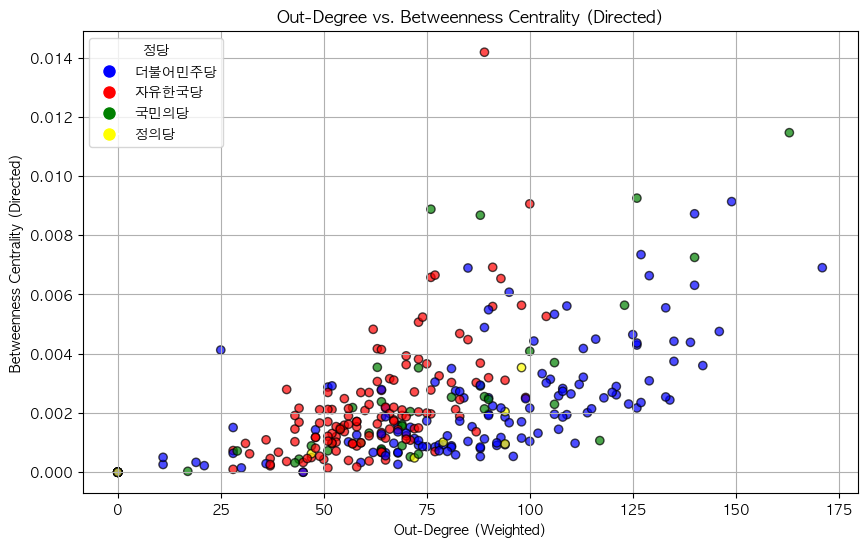

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl


mpl.rcParams['font.family'] = 'AppleGothic'  # macOS의 경우
mpl.rcParams['axes.unicode_minus'] = False


# 엣지 데이터 읽기
edges_df = pd.read_csv('의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이전_edge.csv')

# 노드 데이터 읽기
nodes_df = pd.read_csv('의원데이터/전체데이터/제20대_법안별_전체데이터_node.csv')

# 방향성 그래프 생성
G = nx.DiGraph()

# 노드 추가
for index, row in nodes_df.iterrows():
    G.add_node(row['Id'], 
               Label=row['Label'], 
               Party=row['Party'],
               Reselection=row['Reselection'],
               District_Type=row['District_Type'],
               Gender=row['Gender'],
               Role=row['Role'])

# 엣지 추가
for index, row in edges_df.iterrows():
    G.add_edge(row['Source'], row['Target'],
               weight=1,  # 가중치
               Source_Party=row['Source_Party'],
               Target_Party=row['Target_Party'],
               Source_Reselection=row['Source_Reselection'],
               Target_Reselection=row['Target_Reselection'],
               Source_District_Type=row['Source_District_Type'],
               Target_District_Type=row['Target_District_Type'],
               Source_Gender=row['Source_Gender'],
               Target_Gender=row['Target_Gender'],
               Source_Role=row['Source_Role'],
               Target_Role=row['Target_Role'])

# Out-Degree 중심성 계산 (가중치 고려)
out_degree_centrality = {node: G.out_degree(node, weight='weight') for node in G.nodes()}

# Directed Betweenness 중심성 계산 (가중치 고려)
betweenness_centrality = nx.betweenness_centrality(G, weight='weight', normalized=True)

# 정당별 색상 설정
party_colors = {
    "더불어민주당": "blue",
    "자유한국당": "red",
    "국민의당": "green",
    "정의당": "yellow"
}

# 데이터 준비
x_values = []
y_values = []
colors = []

for node in G.nodes():
    x_values.append(out_degree_centrality[node])
    y_values.append(betweenness_centrality[node])
    party = G.nodes[node]['Party']
    colors.append(party_colors.get(party, "gray"))  # Default color is gray for undefined parties

# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(x_values, y_values, alpha=0.7, edgecolors='k', c=colors)
plt.title('Out-Degree vs. Betweenness Centrality (Directed)')
plt.xlabel('Out-Degree (Weighted)')
plt.ylabel('Betweenness Centrality (Directed)')
plt.grid(True)

# 범례 추가
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='더불어민주당'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='자유한국당'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='국민의당'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label='정의당'),
]

plt.legend(handles=legend_elements, title="정당", loc="best")
plt.show()


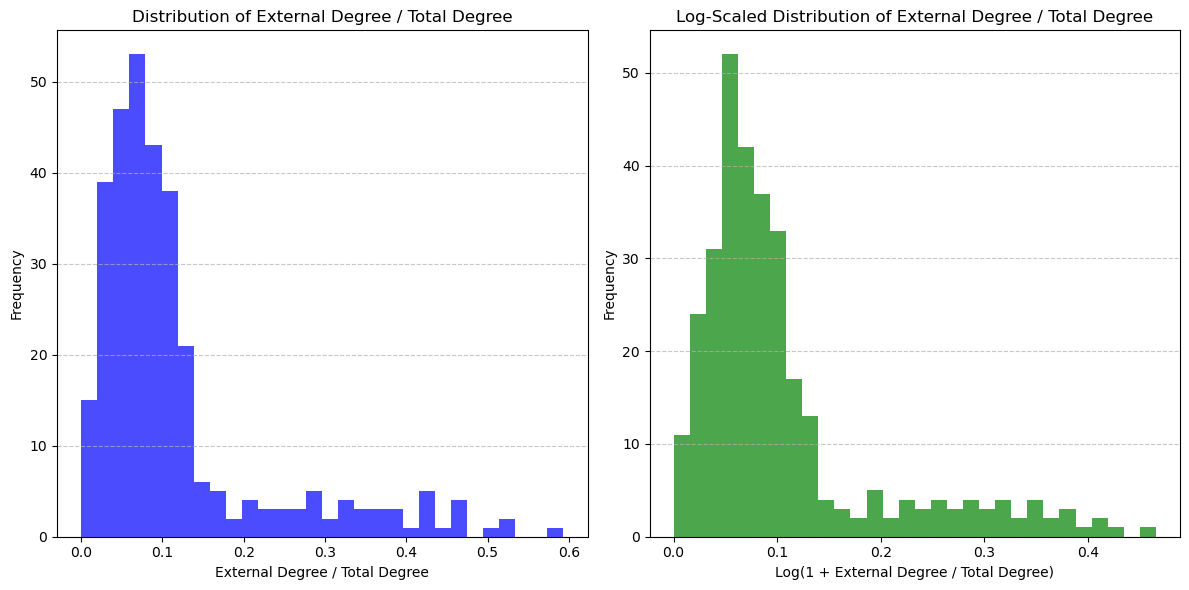

Label  Party Reselection District_Type Gender           Role  ID  AdjustedCentrality
  황주홍   국민의당          재선           지역구      남 Representative 황주홍            0.003955
  이동섭   국민의당          초선          비례대표      남 Representative 이동섭            0.003653
  김경진   국민의당          초선           지역구      남 Representative 김경진            0.002647
  최도자   국민의당          초선          비례대표      여 Representative 최도자            0.002165
  김관영   국민의당          재선           지역구      남 Representative 김관영            0.001798
  주승용   국민의당          4선           지역구      남 Representative 주승용            0.001710
  정성호 더불어민주당          3선           지역구      남 Representative 정성호            0.001586
  이찬열 더불어민주당          3선           지역구      남 Representative 이찬열            0.001562
  김수민   국민의당          초선          비례대표      여 Representative 김수민            0.001543
  유성엽   국민의당          3선           지역구      남 Representative 유성엽            0.001446
  이언주 더불어민주당          재선           지역구      여 Representative 이언주 

In [6]:
    import pandas as pd
    import networkx as nx
    import matplotlib.pyplot as plt
    import numpy as np

    # 엣지 데이터 읽기
    edges_df = pd.read_csv('의원데이터/전체데이터/제20대_법안별_전체데이터_edge.csv')
    nodes_df = pd.read_csv('의원데이터/전체데이터/제20대_법안별_전체데이터_node.csv')

    # 방향성 그래프 생성
    G = nx.DiGraph()

    # 노드 추가
    for index, row in nodes_df.iterrows():
        G.add_node(row['Id'], 
                Label=row['Label'], 
                Party=row['Party'],
                Reselection=row['Reselection'],
                District_Type=row['District_Type'],
                Gender=row['Gender'],
                Role=row['Role'])

    # 엣지 추가
    for index, row in edges_df.iterrows():
        G.add_edge(row['Source'], row['Target'],
                weight=1,
                Source_Party=row['Source_Party'],
                Target_Party=row['Target_Party'],
                Source_Reselection=row['Source_Reselection'],
                Target_Reselection=row['Target_Reselection'],
                Source_District_Type=row['Source_District_Type'],
                Target_District_Type=row['Target_District_Type'],
                Source_Gender=row['Source_Gender'],
                Target_Gender=row['Target_Gender'],
                Source_Role=row['Source_Role'],
                Target_Role=row['Target_Role'])

    # Function to calculate top nodes with full details and log-adjusted centrality
    def calculate_top_nodes_with_log_adjusted_centrality(graph, top_n=20):
        """
        Calculate weighted directed betweenness centrality and adjust by 
        log-scaled (degree with external party connections / total degree).
        Return the top N nodes with their full details (attributes) by the adjusted centrality.
        """
        # Compute weighted directed betweenness centrality
        betweenness_centrality = nx.betweenness_centrality(graph, weight='weight', normalized=True)

        # Compute the external party degree adjustment factor
        adjusted_centrality = {}
        ratios = []
        
        for node in graph.nodes:
            # Total degree
            total_degree = graph.degree(node)
            # External degree (connections to nodes with a different party)
            external_degree = sum(
                1 for neighbor in graph.neighbors(node)
                if graph.nodes[node].get('Party') != graph.nodes[neighbor].get('Party')
            )
            # Avoid division by zero
            adjustment_factor = external_degree / total_degree if total_degree > 0 else 0
            ratios.append(adjustment_factor)
            # Apply log scale transformation
            log_adjustment_factor = np.log1p(adjustment_factor)
            # Adjust centrality
            adjusted_centrality[node] = betweenness_centrality[node] * log_adjustment_factor

        # Sort nodes by adjusted centrality
        sorted_nodes = sorted(adjusted_centrality.items(), key=lambda x: x[1], reverse=True)
        
        # Get top N nodes with full details
        top_nodes = []
        for node, centrality in sorted_nodes[:top_n]:
            node_details = graph.nodes[node]
            node_details['ID'] = node
            node_details['AdjustedCentrality'] = centrality
            top_nodes.append(node_details)

        # Convert to DataFrame for better visualization
        df = pd.DataFrame(top_nodes)
        
        # Plot the distributions of external_degree / total_degree
        log_ratios = [np.log1p(r) for r in ratios]

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.hist(ratios, bins=30, color='blue', alpha=0.7)
        plt.title('Distribution of External Degree / Total Degree')
        plt.xlabel('External Degree / Total Degree')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.subplot(1, 2, 2)
        plt.hist(log_ratios, bins=30, color='green', alpha=0.7)
        plt.title('Log-Scaled Distribution of External Degree / Total Degree')
        plt.xlabel('Log(1 + External Degree / Total Degree)')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        return df


    # Get top 20 nodes with log-adjusted centrality and plot distributions
    top_20_nodes_df = calculate_top_nodes_with_log_adjusted_centrality(G, top_n=20)

    # Display the DataFrame in a clean format
    print(top_20_nodes_df.to_string(index=False))


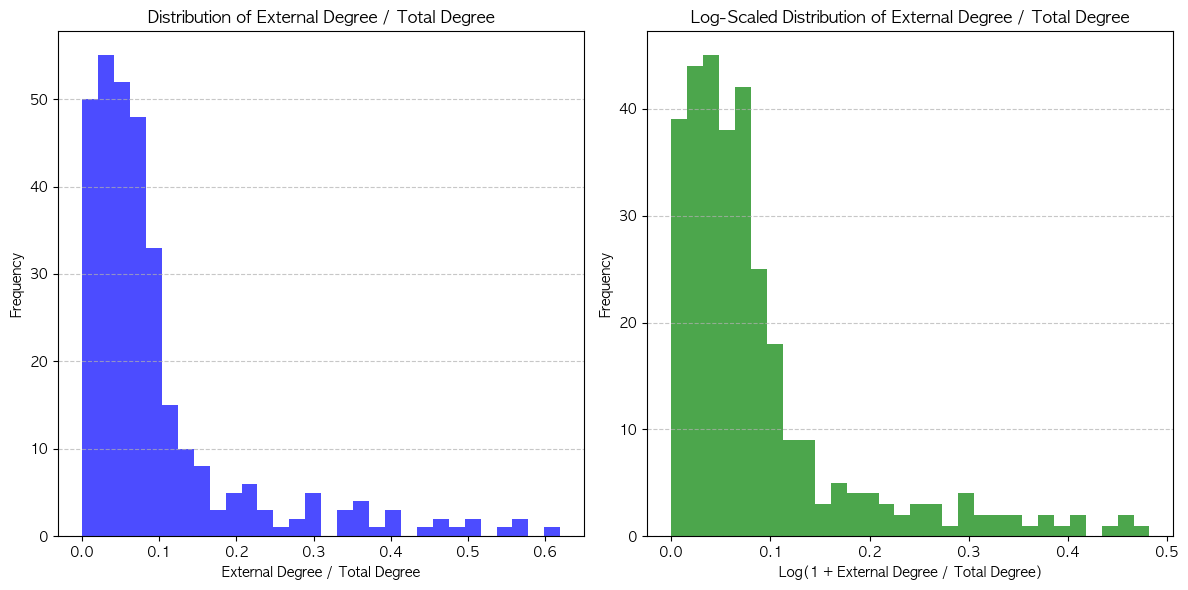

Label  Party Reselection District_Type Gender           Role  ID  AdjustedCentrality
  황주홍   국민의당          재선           지역구      남 Representative 황주홍            0.004618
  김관영   국민의당          재선           지역구      남 Representative 김관영            0.003155
  최도자   국민의당          초선          비례대표      여 Representative 최도자            0.002739
  김경진   국민의당          초선           지역구      남 Representative 김경진            0.002033
  이찬열 더불어민주당          3선           지역구      남 Representative 이찬열            0.001912
  김종대    정의당          초선          비례대표      남 Representative 김종대            0.001704
  유성엽   국민의당          3선           지역구      남 Representative 유성엽            0.001686
  정성호 더불어민주당          3선           지역구      남 Representative 정성호            0.001661
  주승용   국민의당          4선           지역구      남 Representative 주승용            0.001598
  김삼화   국민의당          초선          비례대표      여 Representative 김삼화            0.001257
  정동영   국민의당          4선           지역구      남 Representative 정동영 

In [17]:
    import pandas as pd
    import networkx as nx
    import matplotlib.pyplot as plt
    import numpy as np

    # 엣지 데이터 읽기
    edges_df = pd.read_csv('의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이전_edge.csv')
    nodes_df = pd.read_csv('의원데이터/전체데이터/제20대_법안별_전체데이터_node.csv')

    # 방향성 그래프 생성
    G = nx.DiGraph()

    # 노드 추가
    for index, row in nodes_df.iterrows():
        G.add_node(row['Id'], 
                Label=row['Label'], 
                Party=row['Party'],
                Reselection=row['Reselection'],
                District_Type=row['District_Type'],
                Gender=row['Gender'],
                Role=row['Role'])

    # 엣지 추가
    for index, row in edges_df.iterrows():
        G.add_edge(row['Source'], row['Target'],
                weight=1,
                Source_Party=row['Source_Party'],
                Target_Party=row['Target_Party'],
                Source_Reselection=row['Source_Reselection'],
                Target_Reselection=row['Target_Reselection'],
                Source_District_Type=row['Source_District_Type'],
                Target_District_Type=row['Target_District_Type'],
                Source_Gender=row['Source_Gender'],
                Target_Gender=row['Target_Gender'],
                Source_Role=row['Source_Role'],
                Target_Role=row['Target_Role'])

    # Function to calculate top nodes with full details and log-adjusted centrality
    def calculate_top_nodes_with_log_adjusted_centrality(graph, top_n=20):
        """
        Calculate weighted directed betweenness centrality and adjust by 
        log-scaled (degree with external party connections / total degree).
        Return the top N nodes with their full details (attributes) by the adjusted centrality.
        """
        # Compute weighted directed betweenness centrality
        betweenness_centrality = nx.betweenness_centrality(graph, weight='weight', normalized=True)

        # Compute the external party degree adjustment factor
        adjusted_centrality = {}
        ratios = []
        
        for node in graph.nodes:
            # Total degree
            total_degree = graph.degree(node)
            # External degree (connections to nodes with a different party)
            external_degree = sum(
                1 for neighbor in graph.neighbors(node)
                if graph.nodes[node].get('Party') != graph.nodes[neighbor].get('Party')
            )
            # Avoid division by zero
            adjustment_factor = external_degree / total_degree if total_degree > 0 else 0
            ratios.append(adjustment_factor)
            # Apply log scale transformation
            log_adjustment_factor = np.log1p(adjustment_factor)
            # Adjust centrality
            adjusted_centrality[node] = betweenness_centrality[node] * log_adjustment_factor

        # Sort nodes by adjusted centrality
        sorted_nodes = sorted(adjusted_centrality.items(), key=lambda x: x[1], reverse=True)
        
        # Get top N nodes with full details
        top_nodes = []
        for node, centrality in sorted_nodes[:top_n]:
            node_details = graph.nodes[node]
            node_details['ID'] = node
            node_details['AdjustedCentrality'] = centrality
            top_nodes.append(node_details)

        # Convert to DataFrame for better visualization
        df = pd.DataFrame(top_nodes)
        
        # Plot the distributions of external_degree / total_degree
        log_ratios = [np.log1p(r) for r in ratios]

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.hist(ratios, bins=30, color='blue', alpha=0.7)
        plt.title('Distribution of External Degree / Total Degree')
        plt.xlabel('External Degree / Total Degree')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.subplot(1, 2, 2)
        plt.hist(log_ratios, bins=30, color='green', alpha=0.7)
        plt.title('Log-Scaled Distribution of External Degree / Total Degree')
        plt.xlabel('Log(1 + External Degree / Total Degree)')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        return df


    # Get top 20 nodes with log-adjusted centrality and plot distributions
    top_20_nodes_df = calculate_top_nodes_with_log_adjusted_centrality(G, top_n=20)

    # Display the DataFrame in a clean format
    print(top_20_nodes_df.to_string(index=False))


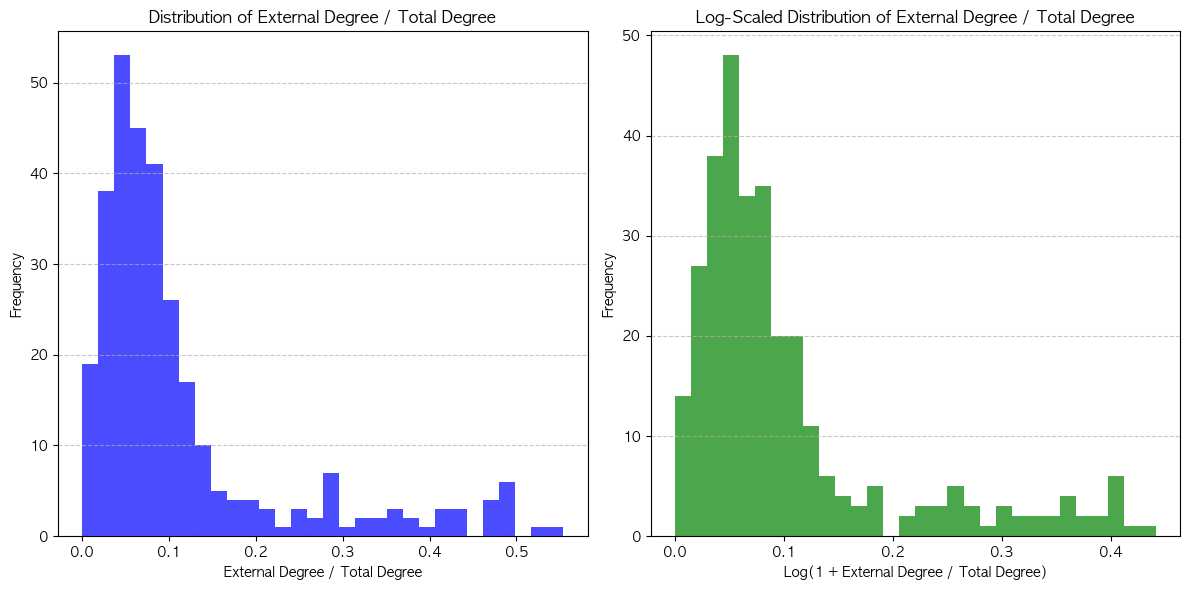

Label  Party Reselection District_Type Gender           Role  ID  AdjustedCentrality
  이동섭  바른미래당          초선          비례대표      남 Representative 이동섭            0.007626
  김경진  민주평화당          초선           지역구      남 Representative 김경진            0.003468
  황주홍  민주평화당          재선           지역구      남 Representative 황주홍            0.003283
  이찬열  바른미래당          3선           지역구      남 Representative 이찬열            0.002970
  정인화  민주평화당          초선           지역구      남 Representative 정인화            0.002450
  이학재  바른미래당          3선           지역구      남 Representative 이학재            0.002161
  김세연  바른미래당          3선           지역구      남 Representative 김세연            0.002070
  정운천  바른미래당          초선           지역구      남 Representative 정운천            0.001869
  주승용  바른미래당          4선           지역구      남 Representative 주승용            0.001647
  정동영  민주평화당          4선           지역구      남 Representative 정동영            0.001467
  유동수 더불어민주당          초선           지역구      남 Representative 유동수 

In [22]:
    import pandas as pd
    import networkx as nx
    import matplotlib.pyplot as plt
    import numpy as np

    # 엣지 데이터 읽기
    edges_df = pd.read_csv('의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이후_edge.csv')
    nodes_df = pd.read_csv('의원데이터/전체데이터/제20대_법안별_전체데이터__2018-02-13_이후_node.csv')

    # 방향성 그래프 생성
    G = nx.DiGraph()

    # 노드 추가
    for index, row in nodes_df.iterrows():
        G.add_node(row['Id'], 
                Label=row['Label'], 
                Party=row['Party'],
                Reselection=row['Reselection'],
                District_Type=row['District_Type'],
                Gender=row['Gender'],
                Role=row['Role'])

    # 엣지 추가
    for index, row in edges_df.iterrows():
        G.add_edge(row['Source'], row['Target'],
                weight=1,
                Source_Party=row['Source_Party'],
                Target_Party=row['Target_Party'],
                Source_Reselection=row['Source_Reselection'],
                Target_Reselection=row['Target_Reselection'],
                Source_District_Type=row['Source_District_Type'],
                Target_District_Type=row['Target_District_Type'],
                Source_Gender=row['Source_Gender'],
                Target_Gender=row['Target_Gender'],
                Source_Role=row['Source_Role'],
                Target_Role=row['Target_Role'])

    # Function to calculate top nodes with full details and log-adjusted centrality
    def calculate_top_nodes_with_log_adjusted_centrality(graph, top_n=20):
        """
        Calculate weighted directed betweenness centrality and adjust by 
        log-scaled (degree with external party connections / total degree).
        Return the top N nodes with their full details (attributes) by the adjusted centrality.
        """
        # Compute weighted directed betweenness centrality
        betweenness_centrality = nx.betweenness_centrality(graph, weight='weight', normalized=True)

        # Compute the external party degree adjustment factor
        adjusted_centrality = {}
        ratios = []
        
        for node in graph.nodes:
            # Total degree
            total_degree = graph.degree(node)
            # External degree (connections to nodes with a different party)
            external_degree = sum(
                1 for neighbor in graph.neighbors(node)
                if graph.nodes[node].get('Party') != graph.nodes[neighbor].get('Party')
            )
            # Avoid division by zero
            adjustment_factor = external_degree / total_degree if total_degree > 0 else 0
            ratios.append(adjustment_factor)
            # Apply log scale transformation
            log_adjustment_factor = np.log1p(adjustment_factor)
            # Adjust centrality
            adjusted_centrality[node] = betweenness_centrality[node] * log_adjustment_factor

        # Sort nodes by adjusted centrality
        sorted_nodes = sorted(adjusted_centrality.items(), key=lambda x: x[1], reverse=True)
        
        # Get top N nodes with full details
        top_nodes = []
        for node, centrality in sorted_nodes[:top_n]:
            node_details = graph.nodes[node]
            node_details['ID'] = node
            node_details['AdjustedCentrality'] = centrality
            top_nodes.append(node_details)

        # Convert to DataFrame for better visualization
        df = pd.DataFrame(top_nodes)
        
        # Plot the distributions of external_degree / total_degree
        log_ratios = [np.log1p(r) for r in ratios]

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.hist(ratios, bins=30, color='blue', alpha=0.7)
        plt.title('Distribution of External Degree / Total Degree')
        plt.xlabel('External Degree / Total Degree')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.subplot(1, 2, 2)
        plt.hist(log_ratios, bins=30, color='green', alpha=0.7)
        plt.title('Log-Scaled Distribution of External Degree / Total Degree')
        plt.xlabel('Log(1 + External Degree / Total Degree)')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        return df


    # Get top 20 nodes with log-adjusted centrality and plot distributions
    top_20_nodes_df = calculate_top_nodes_with_log_adjusted_centrality(G, top_n=20)

    # Display the DataFrame in a clean format
    print(top_20_nodes_df.to_string(index=False))


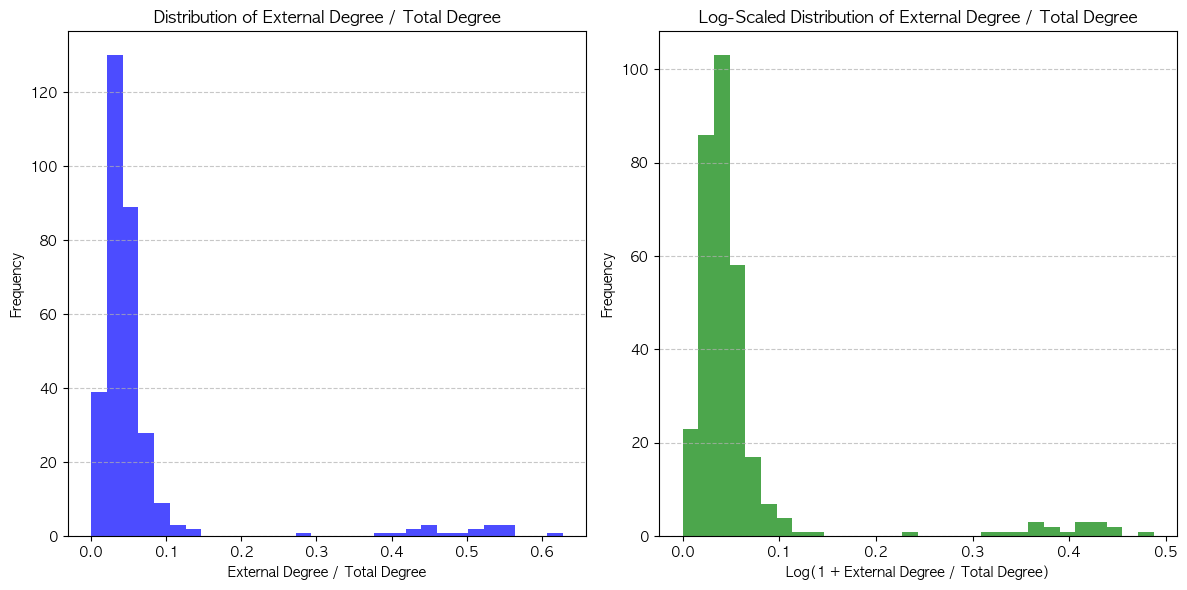

Label  Party Reselection District_Type Gender           Role  ID  AdjustedCentrality
  양향자    무소속          초선           지역구      여 Representative 양향자            0.006345
  조정훈   시대전환          초선          비례대표      남 Representative 조정훈            0.003607
  이용호   국민의힘          재선           지역구      남 Representative 이용호            0.002936
  최연숙   국민의당          초선          비례대표      여 Representative 최연숙            0.002548
  양정숙   국민의힘          초선          비례대표      여 Representative 양정숙            0.002425
  용혜인  기본소득당          초선          비례대표      여 Representative 용혜인            0.002398
  류호정    정의당          초선          비례대표      여 Representative 류호정            0.001533
  강민정  열린민주당          초선          비례대표      여 Representative 강민정            0.001219
  이은주    정의당          초선          비례대표      여 Representative 이은주            0.001110
  권은희   국민의당          3선          비례대표      여 Representative 권은희            0.001103
  김예지   국민의힘          초선          비례대표      여 Representative 김예지 

In [23]:
    import pandas as pd
    import networkx as nx
    import matplotlib.pyplot as plt
    import numpy as np

    # 엣지 데이터 읽기
    edges_df = pd.read_csv('의원데이터/전체데이터/제21대_법안별_전체데이터_edge.csv')
    nodes_df = pd.read_csv('의원데이터/전체데이터/제21대_법안별_전체데이터_node.csv')

    # 방향성 그래프 생성
    G = nx.DiGraph()

    # 노드 추가
    for index, row in nodes_df.iterrows():
        G.add_node(row['Id'], 
                Label=row['Label'], 
                Party=row['Party'],
                Reselection=row['Reselection'],
                District_Type=row['District_Type'],
                Gender=row['Gender'],
                Role=row['Role'])

    # 엣지 추가
    for index, row in edges_df.iterrows():
        G.add_edge(row['Source'], row['Target'],
                weight=1,
                Source_Party=row['Source_Party'],
                Target_Party=row['Target_Party'],
                Source_Reselection=row['Source_Reselection'],
                Target_Reselection=row['Target_Reselection'],
                Source_District_Type=row['Source_District_Type'],
                Target_District_Type=row['Target_District_Type'],
                Source_Gender=row['Source_Gender'],
                Target_Gender=row['Target_Gender'],
                Source_Role=row['Source_Role'],
                Target_Role=row['Target_Role'])

    # Function to calculate top nodes with full details and log-adjusted centrality
    def calculate_top_nodes_with_log_adjusted_centrality(graph, top_n=20):
        """
        Calculate weighted directed betweenness centrality and adjust by 
        log-scaled (degree with external party connections / total degree).
        Return the top N nodes with their full details (attributes) by the adjusted centrality.
        """
        # Compute weighted directed betweenness centrality
        betweenness_centrality = nx.betweenness_centrality(graph, weight='weight', normalized=True)

        # Compute the external party degree adjustment factor
        adjusted_centrality = {}
        ratios = []
        
        for node in graph.nodes:
            # Total degree
            total_degree = graph.degree(node)
            # External degree (connections to nodes with a different party)
            external_degree = sum(
                1 for neighbor in graph.neighbors(node)
                if graph.nodes[node].get('Party') != graph.nodes[neighbor].get('Party')
            )
            # Avoid division by zero
            adjustment_factor = external_degree / total_degree if total_degree > 0 else 0
            ratios.append(adjustment_factor)
            # Apply log scale transformation
            log_adjustment_factor = np.log1p(adjustment_factor)
            # Adjust centrality
            adjusted_centrality[node] = betweenness_centrality[node] * log_adjustment_factor

        # Sort nodes by adjusted centrality
        sorted_nodes = sorted(adjusted_centrality.items(), key=lambda x: x[1], reverse=True)
        
        # Get top N nodes with full details
        top_nodes = []
        for node, centrality in sorted_nodes[:top_n]:
            node_details = graph.nodes[node]
            node_details['ID'] = node
            node_details['AdjustedCentrality'] = centrality
            top_nodes.append(node_details)

        # Convert to DataFrame for better visualization
        df = pd.DataFrame(top_nodes)
        
        # Plot the distributions of external_degree / total_degree
        log_ratios = [np.log1p(r) for r in ratios]

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.hist(ratios, bins=30, color='blue', alpha=0.7)
        plt.title('Distribution of External Degree / Total Degree')
        plt.xlabel('External Degree / Total Degree')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.subplot(1, 2, 2)
        plt.hist(log_ratios, bins=30, color='green', alpha=0.7)
        plt.title('Log-Scaled Distribution of External Degree / Total Degree')
        plt.xlabel('Log(1 + External Degree / Total Degree)')
        plt.ylabel('Frequency')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        return df


    # Get top 20 nodes with log-adjusted centrality and plot distributions
    top_20_nodes_df = calculate_top_nodes_with_log_adjusted_centrality(G, top_n=20)

    # Display the DataFrame in a clean format
    print(top_20_nodes_df.to_string(index=False))
